In [1]:
# Necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords

df = pd.read_csv("cleaned_tickets.csv")
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [2]:
# Vectorise cleaned text
vectorizer = TfidfVectorizer(max_features=1000, min_df=2, maxx_df=0.5)
x = vectorizer.fit_transform(df["Processed Description"])
print(x.shape)

(8469, 1000)


### Text Vectorisation
The clean data was converted into numerical format using IF-IDF vectorisation. This allows for processing the text data by representing each document as a vector of features

In [3]:
#K-Means 
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(x) 
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Processed Description,cluster
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,issue productpurchased billing zip code apprec...,1
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,issue productpurchased change existing product...,2
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,problem productpurchased productpurchased turn...,2
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,issue productpurchased problem youre intereste...,2
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,issue productpurchased note seller responsible...,2


### K-Means clustering
KMean clustering was applied to group similar customer support tickets based on their textual content. This help identify underlying patterns and categories of customer issues.

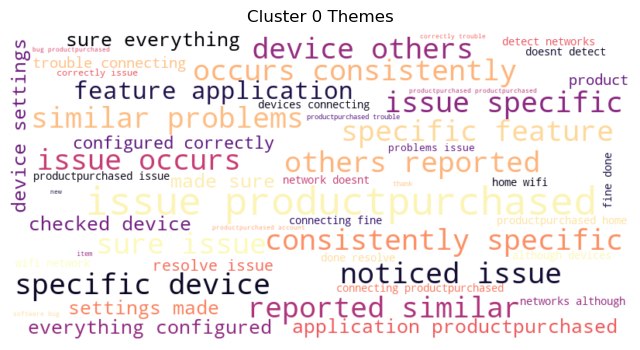

Cluster 0 - Top 5 words:
issue:1388
productpurchased:1327
specific:525
device:518
sure:499



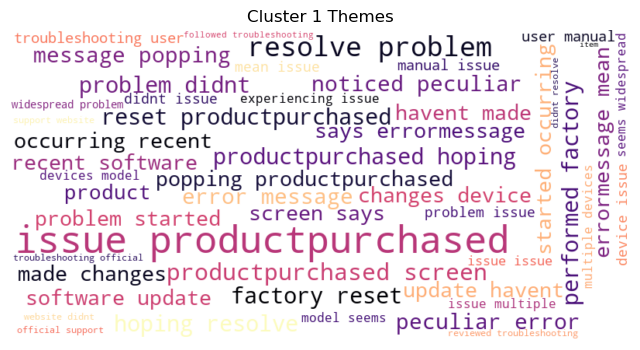

Cluster 1 - Top 5 words:
productpurchased:3515
issue:2684
problem:1654
resolve:779
didnt:736



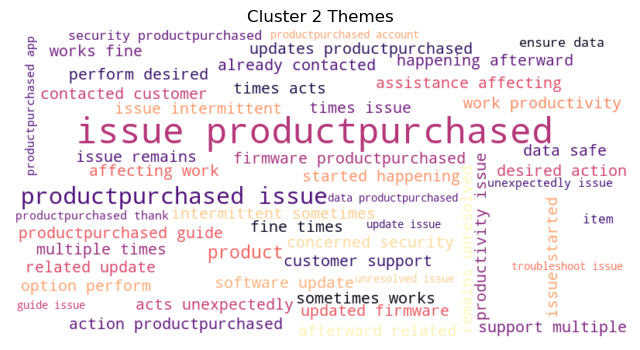

Cluster 2 - Top 5 words:
productpurchased:9206
issue:7458
product:1482
data:1283
times:947



In [17]:
# Word clouds for each cluster
n_clusters = len(df['cluster'].unique())
for i in range(n_clusters):
    cluster_text = " ".join(df[df['cluster'] == i]['Processed Description'])
    #Split into words and count frequencies
    words = re.findall(r'\b[a-zA-Z]{3,}\b', cluster_text.lower()) 
    word_count = Counter(words)
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=50).generate(cluster_text)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Cluster {i} Themes')
    plt.axis('off')
    plt.show()
        # Top 5 words
    top_words = word_count.most_common(5)
    print(f"Cluster {i} - Top 5 words:")
    for word, count in top_words:
        print(f"{word}:{count}")
    print()

Word clouds were generated for each cluster to visualise the most frequent terms, which will help in interpreting the underlying themes of each group. 

In [5]:
# Create topic_mapping 
topic_mapping = {0: "

SyntaxError: unterminated string literal (detected at line 2) (3887256211.py, line 2)